**Random Forest Regressor**

In [2]:
#Carrying over code from previous notebook

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('spotify_music_cleaned.csv')
df.shape

(89583, 20)

In [3]:
#Carrying over code from previous notebook

#one-hot encoding track_genre so all genres are weighted the same instead of being read as numerical rankings
df = pd.get_dummies(df, columns=['track_genre'])

df.shape
#df.columns.tolist()

y = df['popularity']
X = df.drop(columns=['popularity', 'track_id', 'artists', 'track_name', 'album_name', ])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 27)

In [4]:
rf_model = RandomForestRegressor(random_state = 77, n_jobs = -1)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)
rf_rmse = mean_squared_error(y_test, rf_predictions) ** 0.5

print(rf_mae, rf_r2, rf_rmse)

10.116517254399877 0.4690101183839913 14.998597813140863


**Observations**

- While these values still do not clearly represent a pattern and correlation between variables and popularity, using the Random Tree Regressor model produced a significant increase in r squared value from 32.5% to 46.9% of the data being explained by the model.

- I will continue to tweak adjustements to the model and analyze other trends to see if I can find new patterns and get a better accuracy.

In [13]:
importances = rf_model.feature_importances_

feature_importance_series = pd.Series(importances, index=X_train.columns)

mask = feature_importance_series.index.str.startswith('track_genre_')
genre_series = feature_importance_series[mask]
feature_series = feature_importance_series[~mask]
genre_sum = genre_series.sum()

#print(feature_importance_series.sort_values(ascending=False).head(15))

genre_bar = pd.Series({'All Genres Combined': genre_sum})
top_features = feature_series.sort_values(ascending=False).head(10)
combined_sort = pd.concat([top_features, genre_bar]).sort_values(ascending=False)

print(combined_sort)

All Genres Combined    0.396206
duration_ms            0.063849
loudness               0.060405
acousticness           0.058989
danceability           0.057610
speechiness            0.057158
valence                0.056855
tempo                  0.055694
energy                 0.054401
liveness               0.052926
instrumentalness       0.042615
dtype: float64


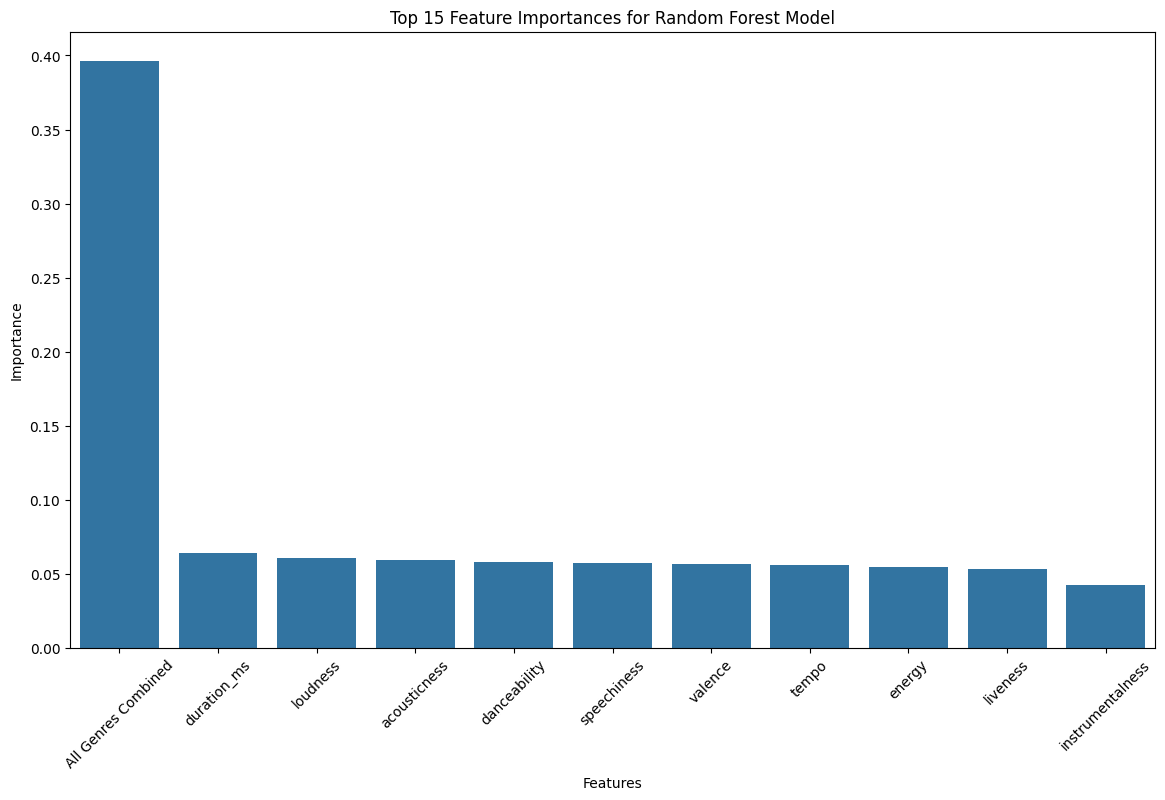

<Figure size 640x480 with 0 Axes>

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize= (14, 8))
sns.barplot(x=combined_sort.index, 
            y=combined_sort.values)

plt.title('Top 15 Feature Importances for Random Forest Model')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')

In [8]:
#hardcoding linear regression values for comparison
mae = 12.0703
r2 = 0.3254
rmse = 16.9053


results = {
    'Linear_Regression': {'MAE': mae, 'R2' : r2, 'RMSE' : rmse},
    'Random_Forest' : {'MAE': rf_mae, 'R2' : rf_r2, 'RMSE' : rf_rmse}
}

comparison_df = pd.DataFrame(results).T
print(comparison_df)

                         MAE       R2       RMSE
Linear_Regression  12.070300  0.32540  16.905300
Random_Forest      10.116517  0.46901  14.998598
